# **Exploratory Data Analysis of Loan Applications**

## **Introduction**

This project explores a dataset containing loan application records from a bank. The goal is to analyze key trends, relationships between applicant attributes and loan decisions, and gain insights into factors affecting loan approvals. I will examine income levels, credit history, property details, and other financial indicators to identify patterns that impact loan approval rates.

## **Objectives**

- Understand the dataset structure and key variables.
- Perform data cleaning and handle missing values.
- Analyze distributions and relationships among variables.
- Conduct statistical tests and build predictive insights using regression models.
- Present key findings with clear explanations.

## **Import Necessary Packages**

In [53]:
# Import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Read the loan application dataset**

In [3]:
# Read the dataset 
df = pd.read_csv("loanapp.csv")

## **1. Descriptive Statistics and Dataset Overview**

In [4]:
# Generate descriptive statistics of the quantitative variables of dataset
descriptive_stats = df.describe().round(2)

# Generate descriptive statistics of the categorical variables of dataset
categorical_stats = df.describe(include='O')

# Display the results
print(
    "Descriptive statistics of the quantitative variables:\n", 
      descriptive_stats, 
      end="\n\n"
)
print("Descriptive statistics of the categorical variables:\n", categorical_stats)

Descriptive statistics of the quantitative variables:
        occupancy  loan_amount  applicant_income  num_units  num_dependants  \
count    1988.00      1988.00           1988.00    1984.00         1985.00   
mean        1.03       143.27             84.68       1.12            0.77   
std         0.19        80.53             87.08       0.44            1.10   
min         1.00         2.00              0.00       1.00            0.00   
25%         1.00       100.00             48.00       1.00            0.00   
50%         1.00       126.00             64.00       1.00            0.00   
75%         1.00       165.00             88.00       1.00            1.00   
max         3.00       980.00            972.00       4.00            8.00   

       monthly_income  purchase_price  liquid_assets  mortage_payment_history  \
count         1988.00         1988.00        1988.00                  1988.00   
mean          5195.22          196.30        4620.33                     1.71   

**Main Trends:**
* **Demographics:**
    - Race: The majority of applicants are identified as white.
    - Male: Most of applicants are identified as male
    - Marital status: Most of the applicants are married
* **Property Type and Purchase Price:**
    - Most applicants purchased a property of type 2.
    - The price of the properties ranges from £25 to £1535 with a median of £163, suggesting most prices falls within the median range with few outliers.
* **Loan Decision:** Most loans were approved by the bank.
* **Loan Amount:** 
    - Loan Amounts vary significantly, with the minimum £2K and the maximum reaching £980k. The median is £126k, suggesting potential outliers.
* **Applicant Income and Monthly Income:** 
    - Applicant Income ranges from £0 to £972k with a median of £64k, suggesting extreme income values.
    - Monthly Income also shows a similar pattern as the values ranges from £0 to £81k with a median of £3.8k, suggesting extreme monthly income values.
* **Occupancy and Dependents:** Most applicants has 1 occupant with no dependents with very few having one.
* **Credit and Mortgage Payment History:** Mortgage Payment History and Consumer Credit History show values skewed toward better credit histories, with most entries at 1 or 2.
* **Liquid Assets:** The median of liquid assets is £38 with significant variation ranging from £0 to £1,000,000, suggesting potential outliers.

## **2. Handling Missing Values**

In [5]:
# Create a DataFrame to display missing values information
missing_values = df.isna().sum()
missing_values = missing_values[missing_values > 0]
missing_proportion = missing_values/len(df)*100
missing_value_df = pd.DataFrame({
    "Column with missing values": missing_values.index,
    "Number of Missing Values": missing_values.values,
    "Proportion of Missing Values": missing_proportion.values,
})
missing_value_df

,Column with missing values,Number of Missing Values,Proportion of Missing Values
0,married,3,0.150905
1,num_units,4,0.201207
2,num_dependants,3,0.150905
3,gender,14,0.704225


In [6]:
# Generate the proportion of uniques values of the columns containing missing values
print(df["married"].value_counts(normalize=True) * 100, end="\n\n")
print(df["num_units"].value_counts(normalize=True) * 100, end="\n\n")
print(df["num_dependants"].value_counts(normalize=True) * 100, end="\n\n")
print(df["gender"].value_counts(normalize=True) * 100)

married
True     65.894207
False    34.105793
Name: proportion, dtype: float64

num_units
1.0    91.381048
2.0     5.544355
3.0     2.520161
4.0     0.554435
Name: proportion, dtype: float64

num_dependants
0.0    59.143577
2.0    16.473552
1.0    15.969773
3.0     6.347607
4.0     1.561713
5.0     0.251889
6.0     0.151134
8.0     0.050378
7.0     0.050378
Name: proportion, dtype: float64

gender
male      81.306991
female    18.693009
Name: proportion, dtype: float64


In [59]:
# Replace missing values in 'married' with its mode value.
# Reason: The 'married' column is binary and only 3 values are missing.
# The mode for 'married' is `True`, with about 66% of married applicants,
# using it to replace the missing values maintains consistency 
# without significantly altering the data.
df["married"] = df["married"].fillna(df["married"].mode()[0])

# Replace missing values in 'num_units' with its mode value.
# Reason: Over 91% of the entries have a value of 1.0, indicating that most applicants have 1 unit.
# Using the mode (1.0) to fill the 4 missing values is appropriate.
df["num_units"] = df["num_units"].fillna(df["num_units"].mode()[0])

# Replace missing values in 'num_dependants' with its mode value
# Reason: The mode for 'num_dependants' is 0.0, with about 59% of applicants having 0 dependents.
# With only 3 missing values, imputing with 0.0 maintains consistency
# without significantly altering the data.
df["num_dependants"] = df["num_dependants"].fillna(df["num_dependants"].mode()[0])

# Replace missing values in 'gender' with its mode value.
# Reason: The 'gender' column is binary and has 14 missing entries.
# Since the mode is 'male', imputing with 'male' is reasonable to preserve the data's distribution.
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])

## **3. Data Visualization**

### **a. Distribution of Loan Amount**

<function matplotlib.pyplot.show(close=None, block=None)>

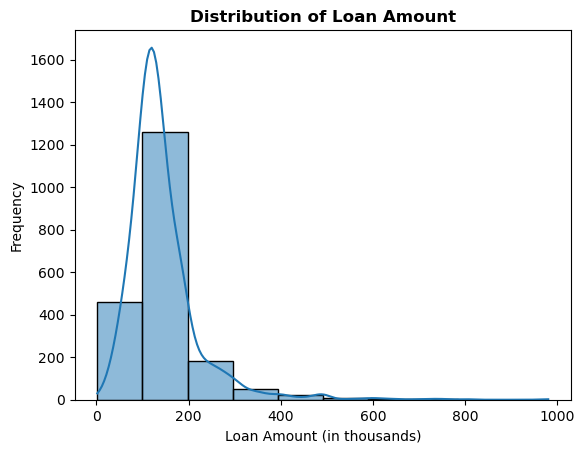

In [8]:
# Visualize the distribution of loan amount in a histogram
sns.histplot(df["loan_amount"], bins=10, kde=True)
plt.xlabel("Loan Amount (in thousands)")
plt.ylabel("Frequency")
plt.title("Distribution of Loan Amount", fontweight='bold')
plt.show

**Interpretation:**

From the histogram, it’s clear that most loan amounts fall between £100k to £200K. As the loan amount increases, the frequency sharply declines, and there are a few high-value loans extending beyond £400K, reaching close to £1 million. This skewness suggests that while smaller loan amounts are far more common, there are occasional larger loans



### **b. The Relationship between the Loan Amount and Applicant Income**

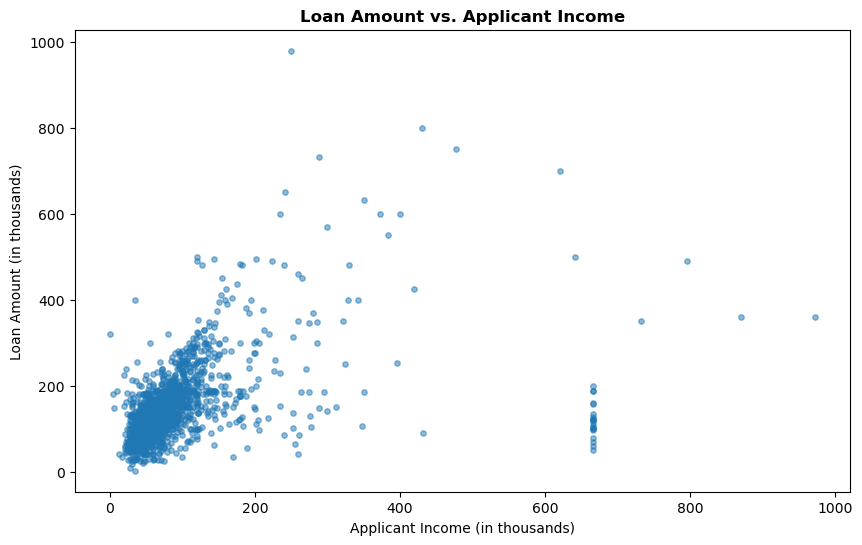

In [9]:
# Visualize the relationship between loan amount and applicant income in a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(x=df["applicant_income"], y=df["loan_amount"], alpha=0.5, s=15)
plt.xlabel("Applicant Income (in thousands)")
plt.ylabel("Loan Amount (in thousands)")
plt.title("Loan Amount vs. Applicant Income", fontweight='bold')
plt.show()

**Interpretation:**

The scatter plot shows that a dense cluster of points is concentrated  clustered in the lower ranges (applicant income under £300K, loan amounts under £200k), suggesting that most applicants fall within this range. Although, there is a positive trend as income increases, loan amount tends to rise, the points are fairly spread out which indicates that income alone does not fully explain loan size. Another point to be noted is that there are a few outliers where applicants with moderate to high incomes have received loans that are either unusually high or low. This suggests that other factors beyond income also play a role in determining loan amounts.

### **c. The Association between Loan Decision and Loan Amount**

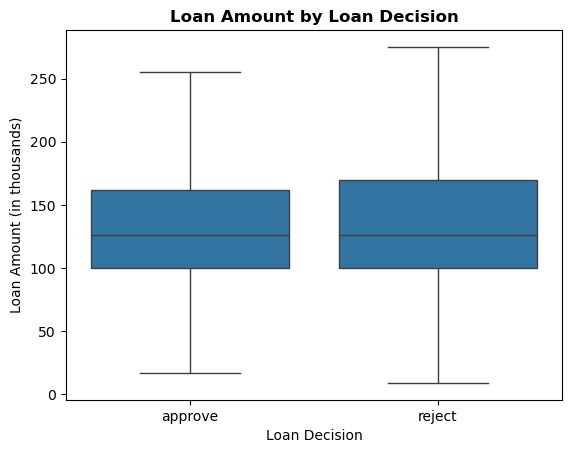

In [10]:
# Sort the data by loan decision
sorted_df = df.sort_values(by="loan_decision")

# Visualize the association between loan decision and loan amount in a boxplot
sns.boxplot(x="loan_decision", y="loan_amount", data=sorted_df, showfliers=False)
plt.xlabel("Loan Decision")
plt.ylabel("Loan Amount (in thousands)")
plt.title("Loan Amount by Loan Decision", fontweight='bold')
plt.show()

**Interpretation:**

The distribution of loan amounts is fairly similar between approved and rejected loans, with rejected loans showing a slightly higher median and wider spread. However, the overlap between the two categories suggests that loan amount alone may not be a strong predictor of loan approval outcomes. Therefore, there is no strong association between loan decision and loan amount


### **d. The Relationship between Loan Amount, Applicant Income, Loan Decision, Property Price and Monthly Income using Semantic Mappings**

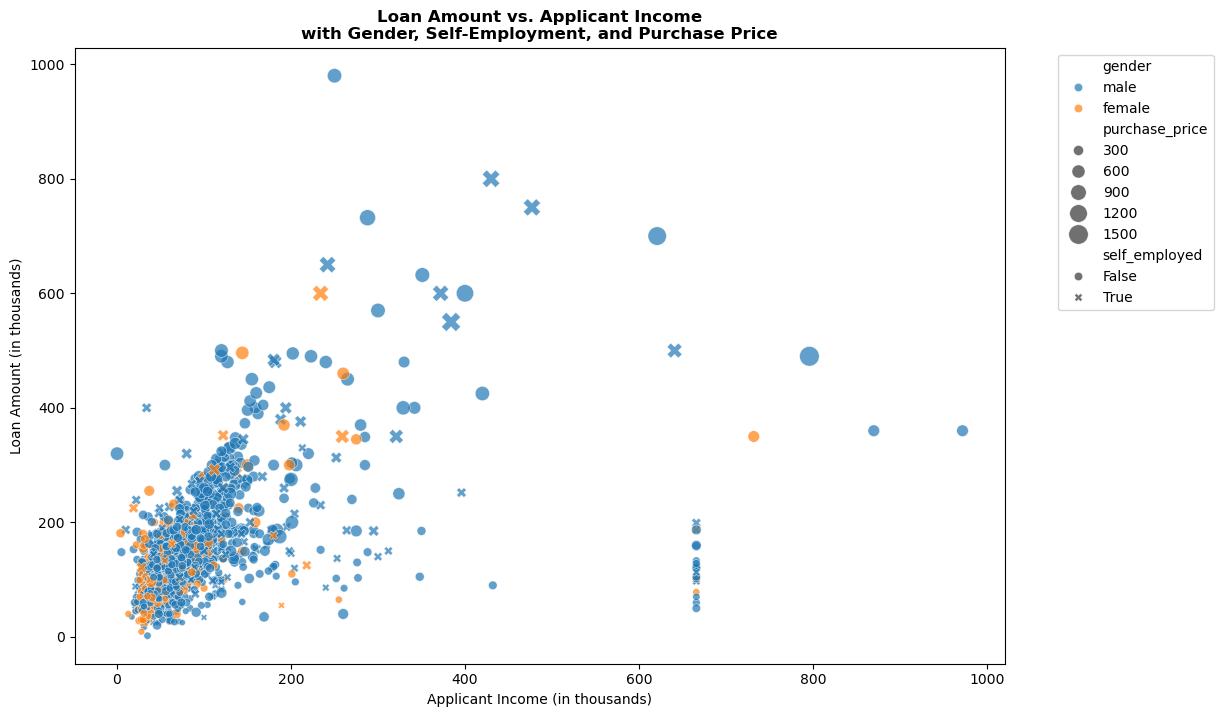

In [11]:
# Visualize The relationship between loan amount, applicant income, gender, 
# self employed and purchase price in a scatter plot using semantic mappings
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x="applicant_income",
    y="loan_amount",
    hue="gender",    # Different colors for approved vs. rejected
    style="self_employed",  # Different markers for self-employed vs. non-self-employed
    size="purchase_price",  # Marker size indicates purchase price (larger = higher purchase price)
    sizes=(20, 200),        # Adjust marker size scale for clarity
    alpha=0.7               # Slight transparency for overlapping points
)
plt.xlabel("Applicant Income (in thousands)")
plt.ylabel("Loan Amount (in thousands)")
plt.title("Loan Amount vs. Applicant Income\nwith Gender, Self-Employment, and Purchase Price", fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

**Interpretation:**

* **Overall Trend:** The scatter plot as observed earlier shows a general upward trend as applicant income increases, loan amount also tends to be higher. However, there is a wide cluster of points in the lower-income range, indicating many applicants fall under moderate incomes and smaller loan amounts.

* **Gender Distribution:** Male and female applicants are spread across all income and loan amount levels, with no clear separation between the two groups.

* **Self-Employment** Self-employed applicants are found across various income and loan amount levels, suggesting no strong correlation between monthly income and loan decision alone.

* **Purchase Price:** The marker sizes, representing purchase price, vary across income levels,  implying that property cost is influenced by factors beyond just applicant income and loan amount.

There appears to be no strong relationship between loan amount, applicant income, gender, self-employed and purchase price indicating that the bank’s approval process likely involves multiple criteria.


## **4. Distribution of Race Categories in the Dataset**

In [12]:
# Create a dataframe representing distribution of Race
race_distribution = pd.DataFrame({
    "Race": df["race"].unique(),
    "Frequency": df["race"].value_counts().values
})

# Change the case of the Race column to title
race_distribution["Race"] = race_distribution["Race"].str.title()

# Display the result
race_distribution

,Race,Frequency
0,White,1680
1,Black,197
2,Hispan,111


**Interpretation:**

The race distribution in the dataset is highly imbalanced, with White applicants (1680, about 84%) forming the overwhelming majority, followed by Black applicants (197) and Hispanic applicants (111). This imbalance suggests that the dataset may not fully represent all racial groups, which could introduce fairness concerns or bias in further analysis or predictive modeling if race is considered as a factor.

## **5. Chi-Square Test: Does Filed Bankruptcy Influence Loan Decisions?**

**Hypotheses:**
* **Null Hypothesis ($𝐻_0$):** There is no association between having filed bankruptcy and the loan decision (i.e., the two variables are independent).

* **Alternative Hypothesis ($𝐻_1$):** There is an association between having filed bankruptcy and the loan decision (i.e., the two variables are not independent).

In [34]:
# Create a contingency table between filed_bankruptcy and loan_decision
contingency_table = pd.crosstab(df["filed_bankruptcy"], df["loan_decision"])

# Display the contingency table
contingency_table.sort_index(ascending=False)

loan_decision,approve,reject
filed_bankruptcy,,
True,76,61
False,1668,183


In [42]:
from scipy.stats import chi2_contingency

# Conduct the chi-square test of independence and display the results
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
alpha = 0.05
print("Chi-square Statistic (χ²):", chi2)
print("Degrees of Freedom (df):", dof)
print("Significance level (α):", alpha)
print("P-value:", p_value)

Chi-square Statistic (χ²): 138.94813686574406
Degrees of Freedom (df): 1
Significance level (α): 0.05
P-value: 4.521035230167944e-32


**Interpretation:**

* The **chi-square statistic** is **138.95** with **1 degree of freedom**.
* The **p-value** is **extremely small (4.52e-32)** and far below the chosen significance level of **0.05**.
* Since the p-value is much smaller than the significance level, **we reject the null hypothesis ($H_0$).**

Thus, there is strong evidence of a statistically significant relationship between filed bankruptcy and loan decision, suggesting that an applicant's bankruptcy status may have an impact on whether their loan is approved or rejected.

## **6. Descriptive Statistics: No Bankruptcy & Approved Loans**

In [52]:
# Filter the dataset based on two criteria:
# 1. Applicants who have not filed bankruptcy.
# 2. Applicants whose loan decision is 'approve'.
subset_df = df[(df["filed_bankruptcy"] == False) & (df["loan_decision"] == "approve")]

# Present descriptive statistics for the subset (for numerical columns)
print("\nDescriptive statistics for the subset:")
subset_df.describe().round(2)


Descriptive statistics for the subset:


,occupancy,loan_amount,applicant_income,num_units,num_dependants,monthly_income,purchase_price,liquid_assets,mortage_payment_history,consumer_credit_history,property_type
count,1668.00,1668.00,1668.00,1668.0,1668.00,1668.00,1668.00,1668.00,1668.00,1668.00,1668.00
mean,1.03,143.29,83.95,1.1,0.75,5262.42,199.70,4890.25,1.68,1.88,1.85
std,0.18,83.12,80.83,0.4,1.09,5234.29,132.71,69102.60,0.54,1.48,0.51
min,1.00,2.00,4.00,1.0,0.00,0.00,25.00,0.00,1.00,1.00,1.00
25%,1.00,100.00,49.00,1.0,0.00,2892.25,130.00,21.76,1.00,1.00,2.00
50%,1.00,126.00,64.00,1.0,0.00,3833.00,165.00,41.00,2.00,1.00,2.00
75%,1.00,162.00,89.00,1.0,1.00,5703.00,228.00,90.12,2.00,2.00,2.00
max,3.00,980.00,870.00,4.0,8.00,72529.00,1535.00,1000000.00,4.00,6.00,3.00


## **7. Statistical Test of the Significance: Does Self-Employment Influence Loan Amounts? A Statistical Test**

**Hypotheses:**

* **Null Hypothesis ($H_0$):** There is no difference in the mean loan amount between self-employed and non-self-employed applicants.

* **Alternative Hypothesis ($H_1$):** There is a statistically significant difference in the mean loan amount between the two groups.

In [55]:
from scipy.stats import ttest_ind

# Extract subsets for self-employed and non-self-employed applicants
loan_self_employed = df[df["self_employed"] == True]["loan_amount"]
loan_non_self_employed = df[df["self_employed"] == False]["loan_amount"]

# Conduct a statistical test of the significance and display the results
t_stat, p_val = ttest_ind(loan_self_employed, loan_non_self_employed, equal_var=False)
alpha = 0.05
print("T-statistic (t):", t_stat)
print("Significance level (α):", alpha)
print("P-value:", p_val, 3)

T-statistic (t): 4.981119283934771
Significance level (α): 0.05
P-value: 1.083127801486668e-06 3


**Interpretation:**

* The **t-statistic** value is **4.98**, which indicates a notable difference between the means of the two subsets.
* The **p-value** is **1.08e-06**, which is significantly smaller than the chosen significance level **(α = 0.05)**.
* Since the **p-value < α**, **we reject the null hypothesis ($H_0$)**.

Thus, there is strong evidence to suggest a significant difference between the means of the two subsets.

## **8. Average Loan Amount by Property Type**

In [13]:
# Define a mapping for property types
property_mapping = {
    1: "Type 1",
    2: "Type 2",
    3: "Type 3"
}

# Create a new categorical column representing property type
df["property_type_categorical"] = pd.Categorical(df["property_type"], categories=property_mapping.keys())

# Convert the values from numeric to string 
df["property_type_categorical"] = df["property_type_categorical"].map(property_mapping)

# Group the dataset by property type and find the average loan amount for each property type
grouped_df = df.groupby("property_type_categorical", observed=True)["loan_amount"].mean().round(0).reset_index()

# Sort the values in a descending order and view the result
grouped_df.sort_values("loan_amount", ascending=False)

,property_type_categorical,loan_amount
1,Type 2,153.0
2,Type 3,151.0
0,Type 1,111.0


**Interpretation:**

The grouped summary analysis shows that properties categorized as Type 2 receive the highest average loan amount (£153K), followed closely by Type 3 (£151K). In contrast, Type 1 properties have a significantly lower average loan amount £111k. This suggests that the type of property is associated with the loan amount with borrowers associated with Type 2 and Type 3 properties tending to secure larger loans compared to those linked with Type 1 properties.

## **9. Linear Regression Analysis: Predicting Loan Amount from Purchase Price**

In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Define the predictor and response variables
X = df[['purchase_price']]  # Independent variable
y = df['loan_amount']         # Dependent variable

# Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate model performance
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Display model output
print("Coefficient (slope):", model.coef_[0])
print("Intercept:", model.intercept_)
print("R-squared:", r2)
print("Mean Squared Error:", mse)

Coefficient (slope): 0.5007829852010246
Intercept: 43.574507290399666
R-squared: 0.6833798652239865
Mean Squared Error: 2272.6123810115114


**Interpretation**

* **Slope (Coefficient):** The slope is approximately **0.50**. This means that for every additional £1,000 in purchase price, the loan amount increases by about £500 on average.

* **Intercept:** The intercept is approximately **43.57**. This suggesting that when the purchase price is £0, the baseline predicted loan amount is roughly £43,570.

* **R-squared:** At 0.683, about 6**8.3%** of the variability in the loan amount is explained by the purchase price which indicates a strong relationship.

* **Mean Squared Error:** The MSE of **2272.61** reflects the average squared prediction error (in thousands squared).

There is a significant and positive association between purchase price and loan amount. Higher purchase prices are associated with larger loans, with the model explaining a substantial portion of the variation in loan amounts.


## **Conclusion**

The exploratory data analysis of the loan application dataset reveals that the it is characterized by considerable variability and skewed distributions in key financial measures such as loan amount and applicant income. Despite the presence of some outliers, the overall trends show that higher applicant incomes tend to be associated with larger loan amounts, though this relationship is influenced by multiple factors.

Visual analysis further enriched the understanding of the data. Histograms of continuous variables, particularly the loan amount, showed a right-skewed distribution, while scatter plots between applicant income and loan amount indicated a moderate positive correlation. Additionally, box plots and semantic mapping visualizations underscored the complex interplay of factors such as loan decision, self-employment status, and purchase price that influence loan amounts and decisions. The highly imbalanced race distribution, with White applicants forming the overwhelming majority, also highlighted potential concerns regarding the representativeness of the data and implications for fairness in further analyses.

Statistical tests provided strong evidence of relationships between key variables. The chi-square test demonstrated a significant association between filed bankruptcy and loan decision, and the t-test revealed a statistically significant difference in mean loan amounts between self-employed and non-self-employed applicants. Grouping the data by property type and calculating average loan amounts showed that property type plays an important role in determining loan size, with Type 2 properties exhibiting the highest average loan amounts. Finally, a linear regression model indicated a robust positive relationship between purchase price and loan amount, explaining about 68.3% of the variance in loan amounts.

Overall, the analysis highlights that while certain financial metrics are strongly related such as the link between purchase price and loan amount, other factors like applicant income, employment status, and even demographic variables interact in complex ways. These findings emphasize the need for a multifaceted approach in predictive modeling and decision-making processes within the loan application context. Future analysis could further investigate additional variables and explore potential causal relationships, providing deeper insights into the determinants of loan approval and risk management.